# EDA(Exploratory Data Analysis)

## 1. Import Libraries

In [1]:
import warnings 
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## 2. Load Dataset

In [3]:
from pathlib import Path

DATA_PATH = Path("/home/surendran-g/Documents/home-credit-default-risk-prediction/data/raw")

application = pd.read_csv(DATA_PATH / "application_train.csv")

In [4]:
print(application.shape)

(307511, 122)


## 3. Missing Value 

### summary table

In [6]:
missing_df = pd.DataFrame({
    'Missing_Count': application.isnull().sum(),
    'Missing_Percentage': round(
        application.isnull().mean() * 100,
        2
    )
})

missing_df = (
    missing_df
    .sort_values(
        by='Missing_Percentage',
        ascending=False
    )
)

missing_df.head(20)

,Missing_Count,Missing_Percentage
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_MEDI,214865,69.87
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


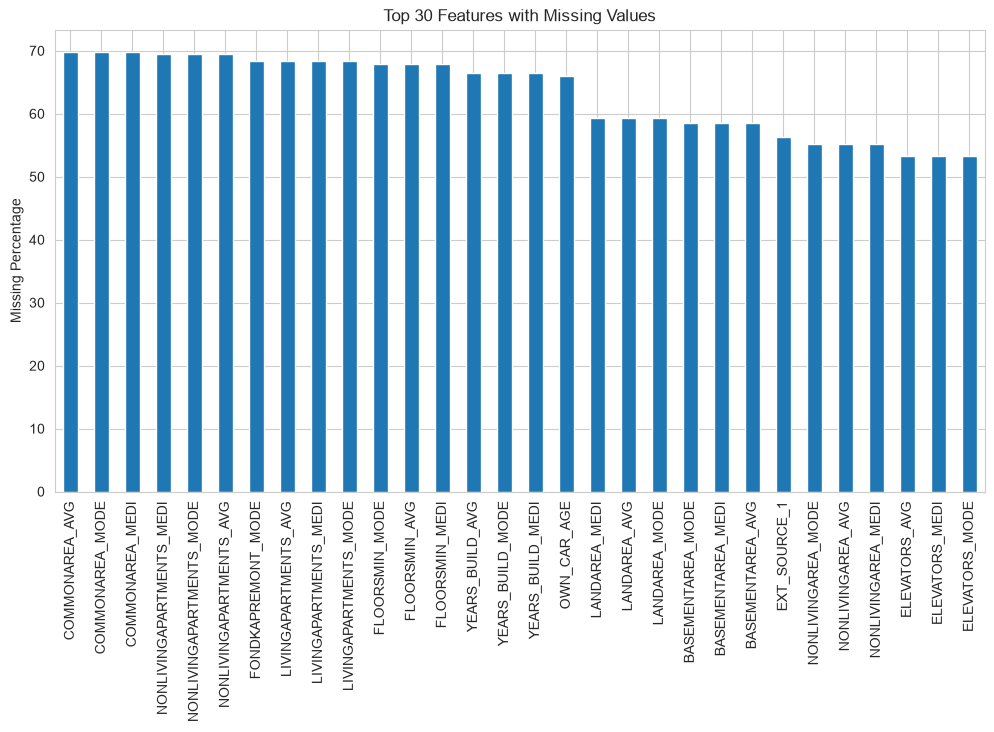

In [8]:
plt.figure(figsize=(12,6))

missing_features[
    'Missing_Percentage'
].head(30).plot(
    kind='bar'
)

plt.title("Top 30 Features with Missing Values")
plt.ylabel("Missing Percentage")
plt.show()

In [9]:
missing_features['Missing_Category'] = pd.cut(
    missing_features['Missing_Percentage'],
    bins=[0, 5, 20, 50, 100],
    labels=[
        'Low (<5%)',
        'Medium (5-20%)',
        'High (20-50%)',
        'Very High (>50%)'
    ]
)

missing_features['Missing_Category'].value_counts()

Missing_Category
Very High (>50%)    41
High (20-50%)        9
Low (<5%)            7
Medium (5-20%)       7
Name: count, dtype: int64

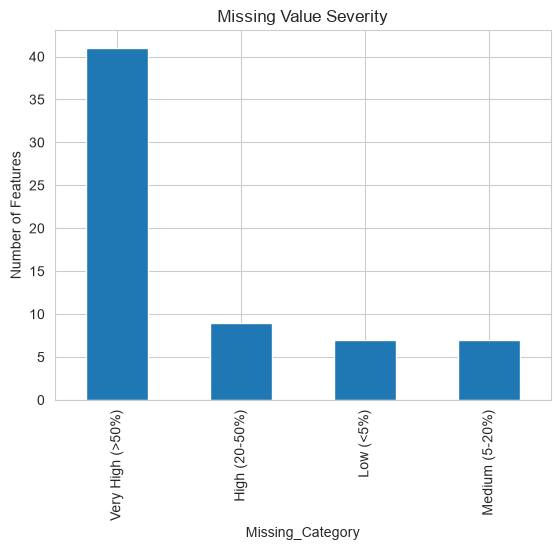

In [10]:
missing_features['Missing_Category'].value_counts().plot(
    kind='bar'
)

plt.title("Missing Value Severity")
plt.ylabel("Number of Features")
plt.show()

In [11]:
high_missing = missing_features[
    missing_features['Missing_Percentage'] > 50
]

high_missing

,Missing_Count,Missing_Percentage,Missing_Category
COMMONAREA_AVG,214865,69.87,Very High (>50%)
COMMONAREA_MODE,214865,69.87,Very High (>50%)
COMMONAREA_MEDI,214865,69.87,Very High (>50%)
NONLIVINGAPARTMENTS_MEDI,213514,69.43,Very High (>50%)
NONLIVINGAPARTMENTS_MODE,213514,69.43,Very High (>50%)
NONLIVINGAPARTMENTS_AVG,213514,69.43,Very High (>50%)
FONDKAPREMONT_MODE,210295,68.39,Very High (>50%)
LIVINGAPARTMENTS_AVG,210199,68.35,Very High (>50%)
LIVINGAPARTMENTS_MEDI,210199,68.35,Very High (>50%)
LIVINGAPARTMENTS_MODE,210199,68.35,Very High (>50%)


In [16]:
missing_by_dtype = pd.DataFrame({
    'dtype': application.dtypes.astype(str),
    'missing_percent': application.isnull().mean() * 100
})

missing_by_dtype.groupby('dtype')['missing_percent'].mean()

dtype
float64    41.965198
int64       0.000000
str        15.535440
Name: missing_percent, dtype: float64

In [19]:
application['missing_count_per_row'] = (
    application.isnull().sum(axis=1)
)

application['missing_count_per_row'].describe()

count    307511.000000
mean         29.763049
std          20.919345
min           0.000000
25%           5.000000
50%          36.000000
75%          49.000000
max          61.000000
Name: missing_count_per_row, dtype: float64

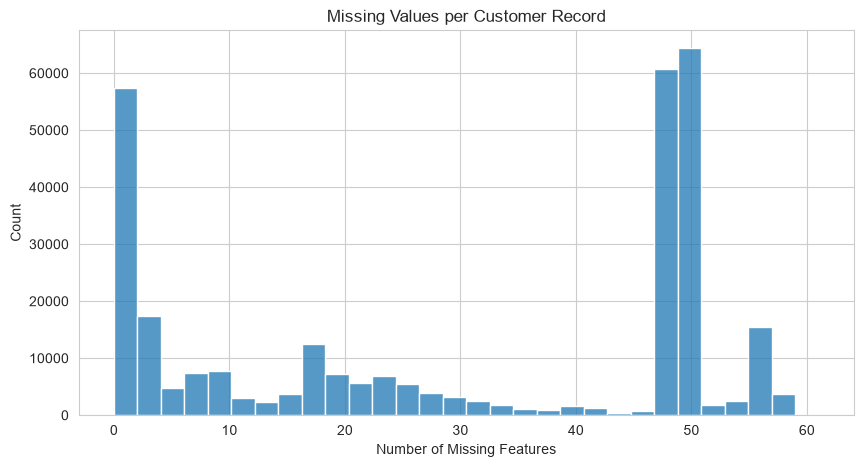

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    application['missing_count_per_row'],
    bins=30
)

plt.title("Missing Values per Customer Record")
plt.xlabel("Number of Missing Features")
plt.show()

In [21]:
complete_features = missing_df[
    missing_df['Missing_Percentage'] == 0
]

print(
    f"Number of complete features: {len(complete_features)}"
)

Number of complete features: 58
